# Baseline Analysis — pub-003 (32k tokens, public split)

Local analysis of `data/full_public_32k.jsonl` + `data/full_public_32k.responses.jsonl`.

In [1]:
import json
import re
import os
import sys
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.isdir(os.path.join(REPO_ROOT, "data")):
    REPO_ROOT = os.getcwd()

sys.path.insert(0, REPO_ROOT)

RUN_TAG = "32k"
RESULTS_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{RUN_TAG}.jsonl")
RESPONSES_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{RUN_TAG}.responses.jsonl")
TOPICS_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{RUN_TAG}_topics.json")
MAX_TOKENS = 32_768
NEAR_CAP_CHARS = 79_000 # 8k tokens ~ 28k chars, 16k tokens ~ 56k chars, 32k tokens ~ 79k

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("REPO_ROOT:", REPO_ROOT)
print("Results:", RESULTS_PATH)

REPO_ROOT: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition
Results: /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/data/full_public_32k.jsonl


## 1. Load data

In [2]:
def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

results   = load_jsonl(RESULTS_PATH)
responses = load_jsonl(RESPONSES_PATH)
public    = load_jsonl(os.path.join(REPO_ROOT, "data", "public.jsonl"))

resp_map = {r["id"]: r["response"] for r in responses}
pub_map  = {p["id"]: p for p in public}

rows = []
for r in results:
    pid  = r["id"]
    p    = pub_map[pid]
    resp = resp_map.get(pid, "")
    rows.append({
        "id":               pid,
        "is_mcq":           r["is_mcq"],
        "correct":          r["correct"],
        "response":         resp,
        "resp_len":         len(resp),
        "question":         p.get("question", ""),
        "q_len":            len(p.get("question", "")),
        "gold":             r["gold"],
        "n_blanks":         len(r["gold"]) if isinstance(r["gold"], list) else 1,
        "has_boxed_letter": bool(re.search(r"\\boxed\{([A-Z])\}", resp)),
        "think_finished":   "</think>" in resp,
        "near_cap_chars":   len(resp) >= NEAR_CAP_CHARS,
    })

df = pd.DataFrame(rows)
mcq = df[df.is_mcq]
ff  = df[~df.is_mcq]

print(f"Loaded {len(df)} rows  |  MCQ: {df.is_mcq.sum()}  |  Free-form: {(~df.is_mcq).sum()}")
print(f"Think finished: {df.think_finished.sum()} / {len(df)} ({100*df.think_finished.mean():.1f}%)")
print(f"Think truncated (no </think>): {(~df.think_finished).sum()} ({100*(~df.think_finished).mean():.1f}%)")

Loaded 1126 rows  |  MCQ: 375  |  Free-form: 751
Think finished: 1115 / 1126 (99.0%)
Think truncated (no </think>): 11 (1.0%)


## 2. Headline metrics

In [3]:
def acc(mask):
    sub = df[mask]
    n, k = len(sub), sub.correct.sum()
    return n, k, 100 * k / n if n else 0

all_n, all_k, all_acc = acc(slice(None))
mcq_n, mcq_k, mcq_acc = acc(df.is_mcq)
ff_n,  ff_k,  ff_acc  = acc(~df.is_mcq)

print(f"{'Split':<15} {'N':>6} {'Correct':>8} {'Accuracy':>9}")
print("-" * 42)
print(f"{'Overall':<15} {all_n:>6} {all_k:>8} {all_acc:>8.2f}%")
print(f"{'MCQ':<15} {mcq_n:>6} {mcq_k:>8} {mcq_acc:>8.2f}%")
print(f"{'Free-form':<15} {ff_n:>6} {ff_k:>8} {ff_acc:>8.2f}%")

Split                N  Correct  Accuracy
------------------------------------------
Overall           1126      741    65.81%
MCQ                375      304    81.07%
Free-form          751      437    58.19%


/tmp/ipykernel_24465/2147076055.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=8)


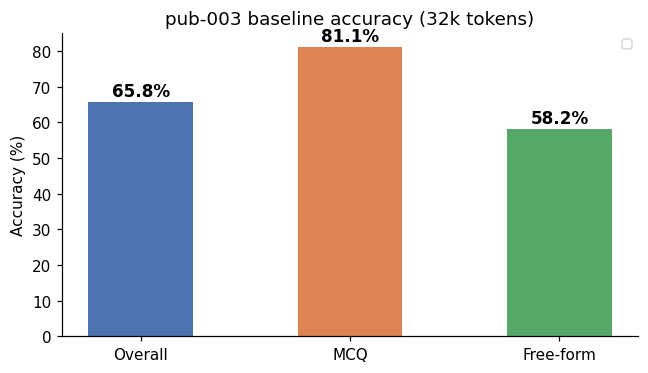

In [6]:
labels = ["Overall", "MCQ", "Free-form"]
accs   = [all_acc, mcq_acc, ff_acc]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(labels, accs, color=colors, width=0.5)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 85)
ax.set_ylabel("Accuracy (%)")
ax.set_title("pub-003 baseline accuracy (32k tokens)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 3. MCQ (basic)

Format compliance and wrong-MCQ failure modes. No sample dumps — see `baseline_analysis.ipynb` §3 for the 8k deep-dive.

In [7]:
strict_n     = mcq[mcq.has_boxed_letter]
fallback_n   = mcq[~mcq.has_boxed_letter]
strict_correct = strict_n[strict_n.correct]
boxed_rate   = len(strict_correct) / len(strict_n) if len(strict_n) else 0

print("MCQ format compliance")
print(f"  Has \\boxed{{Letter}}:  {len(strict_n):>4}  ({100*len(strict_n)/len(mcq):.1f}%)")
print(f"    → correct:         {len(strict_correct):>4}  ({100*boxed_rate:.1f}% of boxed)")
print(f"  No \\boxed{{Letter}}:   {len(fallback_n):>4}  ({100*len(fallback_n)/len(mcq):.1f}%)")
print(f"    → correct:         {fallback_n.correct.sum():>4}  ({100*fallback_n.correct.mean():.1f}% of fallback)")
print()

wrong_mcq       = mcq[~mcq.correct]
truncated       = (~wrong_mcq.think_finished).sum()
finished_no_box = (wrong_mcq.think_finished & ~wrong_mcq.has_boxed_letter).sum()
wrong_box       = (wrong_mcq.think_finished &  wrong_mcq.has_boxed_letter).sum()

print("Wrong MCQ failure modes")
print(f"  Total wrong:                                {len(wrong_mcq)}")
print(f"  Truncated mid-think (no </think>):          {truncated:>4}  ({100*truncated/len(wrong_mcq):.1f}%)")
print(f"  Think finished, no \\boxed{{Letter}}:        {finished_no_box:>4}  ({100*finished_no_box/len(wrong_mcq):.1f}%)")
print(f"  Think finished, wrong \\boxed{{Letter}}:     {wrong_box:>4}  ({100*wrong_box/len(wrong_mcq):.1f}%)")

MCQ format compliance
  Has \boxed{Letter}:   367  (97.9%)
    → correct:          302  (82.3% of boxed)
  No \boxed{Letter}:      8  (2.1%)
    → correct:            2  (25.0% of fallback)

Wrong MCQ failure modes
  Total wrong:                                71
  Truncated mid-think (no </think>):             4  (5.6%)
  Think finished, no \boxed{Letter}:           2  (2.8%)
  Think finished, wrong \boxed{Letter}:       65  (91.5%)


## 4. Free-form: single vs multi-blank

In [8]:
single = ff[ff.n_blanks == 1]
multi  = ff[ff.n_blanks > 1]

print(f"Single-blank:  {len(single):>4}  acc={100*single.correct.mean():.1f}%")
print(f"Multi-blank:   {len(multi):>4}  acc={100*multi.correct.mean():.1f}%")
print()
print("Multi-blank distribution:")
print(ff.n_blanks.value_counts().sort_index())

Single-blank:   337  acc=61.7%
Multi-blank:    414  acc=55.3%

Multi-blank distribution:
n_blanks
1     337
2     171
3      90
4      59
5      31
6      20
7      12
8      12
9       4
10      5
11      1
12      2
13      1
14      2
15      2
24      1
42      1
Name: count, dtype: int64


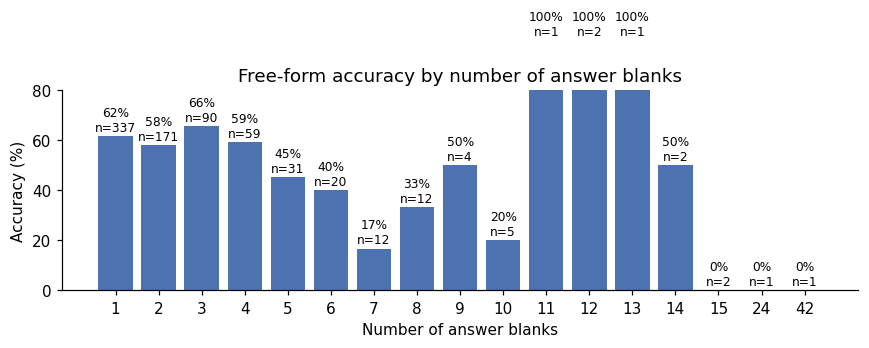

In [9]:
blank_acc = ff.groupby("n_blanks").agg(n=("correct", "count"), acc=("correct", "mean")).reset_index()
blank_acc["acc"] *= 100

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(blank_acc.n_blanks.astype(str), blank_acc.acc, color="#4C72B0")
for bar, row in zip(bars, blank_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.acc + 0.8,
            f"{row.acc:.0f}%\nn={row.n}", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Number of answer blanks")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Free-form accuracy by number of answer blanks")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

## 4b. Free-form format compliance

Post-thinking tail (text after the model closes its thinking block) must yield **N** `\boxed{…}` answers in the **last contiguous group** (`judger.extract_all_boxed`) matching **N** `[ANS]` blanks. **Misformat** = extracted box count ≠ blank count. **Wrong order** (multi-blank only) = count matches and normalized box values are a multiset match with gold but not in blank order (grader is position-sensitive).

In [10]:
import importlib.util
from collections import Counter
from itertools import permutations

_spec = importlib.util.spec_from_file_location(
    "sft_prompt", os.path.join(REPO_ROOT, "scripts", "sft_prompt.py")
)
_sft_prompt = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_sft_prompt)
extract_all_boxed = _sft_prompt.extract_all_boxed


THINK_END = "</" + "redacted_thinking>"


def response_tail(resp: str) -> str:
    end = resp.rfind(THINK_END)
    return resp[end + len(THINK_END):] if end >= 0 else resp


def count_raw_boxed(text: str) -> int:
    n, start = 0, 0
    while True:
        idx = text.find("\\boxed{", start)
        if idx < 0:
            break
        n += 1
        i = idx + len("\\boxed{")
        depth = 1
        while i < len(text) and depth > 0:
            if text[i] == "{":
                depth += 1
            elif text[i] == "}":
                depth -= 1
            i += 1
        start = i
    return n


_PERMUTE_ORDER_MAX_BLANKS = 8


def _norm_box(judger, s: str) -> str:
    return judger.normalize_answer(s)


def _multiset_norm_ok(judger, boxes, gold) -> bool:
    if len(boxes) != len(gold):
        return False
    pb = [_norm_box(judger, b) for b in boxes]
    gb = [_norm_box(judger, g) for g in gold]
    return Counter(pb) == Counter(gb)


def _identity_norm_ok(judger, boxes, gold) -> bool:
    if len(boxes) != len(gold):
        return False
    return [_norm_box(judger, b) for b in boxes] == [_norm_box(judger, g) for g in gold]


def _any_order_semantic_ok(judger, boxes, gold) -> bool:
    """Some permutation matches gold slot-wise (judger.is_equal); n capped for cost."""
    n = len(gold)
    if len(boxes) != n or n == 0:
        return False
    if n == 1:
        return judger.is_equal(
            judger.norm_ans_str(boxes[0]), judger.norm_ans_str(gold[0]), options=[]
        )
    if not _multiset_norm_ok(judger, boxes, gold):
        return False
    if _identity_norm_ok(judger, boxes, gold):
        return True
    if n > _PERMUTE_ORDER_MAX_BLANKS:
        return False
    pred_norm = [judger.norm_ans_str(b) for b in boxes]
    gold_norm = [judger.norm_ans_str(g) for g in gold]
    return any(
        all(
            judger.is_equal(pred_norm[perm[i]], gold_norm[i], options=[])
            for i in range(n)
        )
        for perm in permutations(range(n))
    )


try:
    from judger import Judger

    _judger = Judger(strict_extract=False)
except Exception as _judger_exc:
    _judger = None
    print(f"Order check unavailable ({_judger_exc}).\n")


def _gold_list(gold):
    return gold if isinstance(gold, list) else [gold]


ff_fmt = ff.copy()
_tails = ff_fmt["response"].map(response_tail)
ff_fmt["boxed"] = _tails.map(extract_all_boxed)
ff_fmt["n_extracted"] = ff_fmt["boxed"].map(len)
ff_fmt["n_raw_boxed"] = _tails.map(count_raw_boxed)
ff_fmt["count_ok"] = ff_fmt["n_extracted"] == ff_fmt["n_blanks"]
ff_fmt["no_boxed"] = ff_fmt["n_extracted"] == 0
ff_fmt["count_short"] = (ff_fmt["n_extracted"] > 0) & (ff_fmt["n_extracted"] < ff_fmt["n_blanks"])
ff_fmt["count_long"] = ff_fmt["n_extracted"] > ff_fmt["n_blanks"]
ff_fmt["non_contiguous"] = ff_fmt["n_raw_boxed"] > ff_fmt["n_extracted"]
_has_think_tags = ff_fmt["think_finished"].any()
ff_fmt["format_bad"] = ~ff_fmt["count_ok"]

if _judger is not None:
    ff_fmt["multiset_norm_ok"] = ff_fmt.apply(
        lambda r: _multiset_norm_ok(_judger, r["boxed"], _gold_list(r["gold"])), axis=1
    )
    ff_fmt["identity_norm_ok"] = ff_fmt.apply(
        lambda r: _identity_norm_ok(_judger, r["boxed"], _gold_list(r["gold"])), axis=1
    )
    ff_fmt["wrong_order"] = (
        ff_fmt["count_ok"]
        & ~ff_fmt["correct"]
        & (ff_fmt["n_blanks"] >= 2)
        & ff_fmt["multiset_norm_ok"]
        & ~ff_fmt["identity_norm_ok"]
    )
    _order_cand = ff_fmt["wrong_order"]
    if _order_cand.any():
        ff_fmt.loc[_order_cand, "wrong_order"] = _order_cand & ff_fmt.loc[_order_cand].apply(
            lambda r: _any_order_semantic_ok(_judger, r["boxed"], _gold_list(r["gold"])),
            axis=1,
        )
else:
    ff_fmt["wrong_order"] = False

count_ok_ff = ff_fmt[ff_fmt.count_ok]
format_bad_ff = ff_fmt[ff_fmt.format_bad]
finished_ff = ff_fmt[ff_fmt.think_finished] if _has_think_tags else ff_fmt

print("Free-form format compliance (judger extract_all_boxed on answer tail)")
if not _has_think_tags:
    print("  (No thinking-close tags in responses — tail = full trace, same judger fallback.)\n")
else:
    print(f"  Think-finished subset: {len(finished_ff)} / {len(ff_fmt)} rows\n")

print(f"  Extracted count == blanks: {len(count_ok_ff):>4}  ({100*len(count_ok_ff)/len(ff_fmt):.1f}% of FF)")
print(f"    → correct (ordered grader): {count_ok_ff.correct.sum():>4}  ({100*count_ok_ff.correct.mean():.1f}% of count-ok)")
_wrong_count_ok = count_ok_ff[~count_ok_ff.correct]
_ff_wrong_order_n = int(ff_fmt.wrong_order.sum())
_ff_wrong_vals_n = len(_wrong_count_ok) - _ff_wrong_order_n
if len(_wrong_count_ok):
    print(f"    → wrong order (n≥2, permuted): {_ff_wrong_order_n:>4}  "
          f"({100*_ff_wrong_order_n/len(_wrong_count_ok):.1f}% of count-ok wrong)")
    print(f"    → wrong values (not reorder): {_ff_wrong_vals_n:>4}  "
          f"({100*_ff_wrong_vals_n/len(_wrong_count_ok):.1f}% of count-ok wrong)")
print(f"  Misformat (count ≠ blanks):  {len(format_bad_ff):>4}  ({100*len(format_bad_ff)/len(ff_fmt):.1f}% of FF)")
print(f"    no \\boxed{{}}:             {format_bad_ff.no_boxed.sum():>4}")
print(f"    too few boxes:             {format_bad_ff.count_short.sum():>4}")
print(f"    too many boxes:            {format_bad_ff.count_long.sum():>4}")
print(f"    → correct (any):           {format_bad_ff.correct.sum():>4}")
print()
print(f"  Extra \\boxed{{}} before last group (raw > extracted): "
      f"{ff_fmt.non_contiguous.sum():>4}  "
      f"({100*ff_fmt.non_contiguous.mean():.1f}% of FF; "
      f"{(ff_fmt.non_contiguous & ff_fmt.count_ok).sum()} still count-ok)")
print()

wrong_ff = ff_fmt[~ff_fmt.correct]
trunc_wrong_ff = (~wrong_ff.think_finished).sum() if _has_think_tags else 0
ff_misformat = (~wrong_ff.count_ok).sum()
ff_fin_no_box = wrong_ff.no_boxed.sum()
ff_fin_short = wrong_ff.count_short.sum()
ff_fin_long = wrong_ff.count_long.sum()
ff_reasoning = wrong_ff.count_ok.sum()
ff_wrong_order = int(wrong_ff.wrong_order.sum())
ff_wrong_values = ff_reasoning - ff_wrong_order

print("Wrong free-form failure modes")
print(f"  Total wrong:                          {len(wrong_ff)}")
if _has_think_tags:
    print(f"  Truncated mid-think:                  {trunc_wrong_ff:>4}  ({100*trunc_wrong_ff/len(wrong_ff):.1f}%)")
print(f"  Misformat (extracted count ≠ blanks): {ff_misformat:>4}  ({100*ff_misformat/len(wrong_ff):.1f}%)")
print(f"    no \\boxed{{}}:                       {ff_fin_no_box:>4}")
print(f"    too few / too many boxes:           {ff_fin_short + ff_fin_long:>4}  "
      f"(short {ff_fin_short}, long {ff_fin_long})")
print(f"  Count ok — wrong values:              {ff_wrong_values:>4}  ({100*ff_wrong_values/len(wrong_ff):.1f}%)")
print(f"  Count ok — wrong order (n≥2):         {ff_wrong_order:>4}  ({100*ff_wrong_order/len(wrong_ff):.1f}%)")
print()

multi_fmt = ff_fmt[ff_fmt.n_blanks > 1]
wrong_multi = multi_fmt[~multi_fmt.correct]
multi_format_bad = (~wrong_multi.count_ok).sum()
print(f"Multi-blank only (n={len(multi_fmt)}): misformat among wrong = "
      f"{multi_format_bad} / {len(wrong_multi)} ({100*multi_format_bad/len(wrong_multi):.1f}% of wrong multi)")
_multi_wrong_order = int(wrong_multi.wrong_order.sum()) if "wrong_order" in wrong_multi.columns else 0
print(f"Multi-blank wrong order (reorder would fix): {_multi_wrong_order} / {len(wrong_multi)}")

Free-form format compliance (judger extract_all_boxed on answer tail)
  Think-finished subset: 746 / 751 rows

  Extracted count == blanks:  723  (96.3% of FF)
    → correct (ordered grader):  437  (60.4% of count-ok)
    → wrong order (n≥2, permuted):    1  (0.3% of count-ok wrong)
    → wrong values (not reorder):  285  (99.7% of count-ok wrong)
  Misformat (count ≠ blanks):    28  (3.7% of FF)
    no \boxed{}:                5
    too few boxes:                8
    too many boxes:              15
    → correct (any):              0

  Extra \boxed{} before last group (raw > extracted):  411  (54.7% of FF; 388 still count-ok)

Wrong free-form failure modes
  Total wrong:                          314
  Truncated mid-think:                     5  (1.6%)
  Misformat (extracted count ≠ blanks):   28  (8.9%)
    no \boxed{}:                          5
    too few / too many boxes:             23  (short 8, long 15)
  Count ok — wrong values:               285  (90.8%)
  Count ok — wrong 

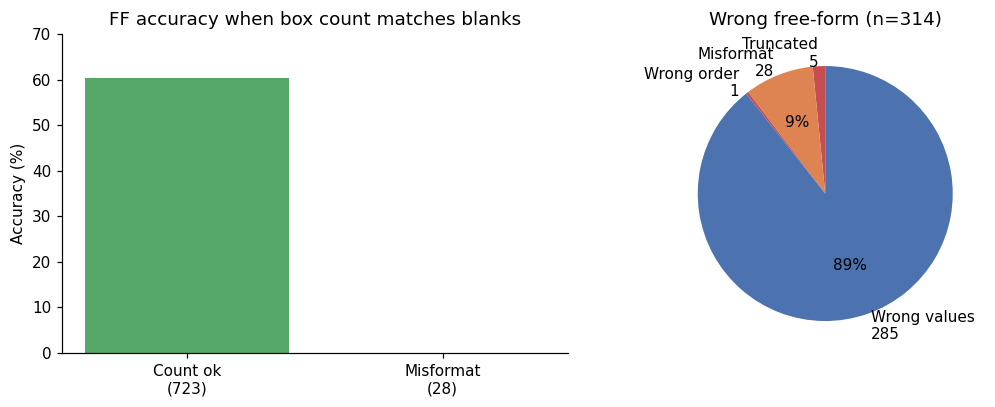

In [11]:
ff_fail_labels = []
ff_fail_sizes = []
ff_fail_colors = []
if _has_think_tags and trunc_wrong_ff:
    ff_fail_labels.append(f"Truncated\n{trunc_wrong_ff}")
    ff_fail_sizes.append(trunc_wrong_ff)
    ff_fail_colors.append("#C44E52")
ff_fail_labels += [
    f"Misformat\n{ff_misformat}",
    f"Wrong order\n{ff_wrong_order}",
    f"Wrong values\n{ff_wrong_values}",
]
ff_fail_sizes += [ff_misformat, ff_wrong_order, ff_wrong_values]
ff_fail_colors += ["#DD8452", "#C44E52", "#4C72B0"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

ax = axes[0]
ok_n = len(count_ok_ff)
bad_n = len(format_bad_ff)
ax.bar(
    [f"Count ok\n({ok_n})", f"Misformat\n({bad_n})"],
    [count_ok_ff.correct.mean() * 100, 0],
    color=["#55A868", "#DD8452"],
)
ax.set_ylabel("Accuracy (%)")
ax.set_title("FF accuracy when box count matches blanks")
ax.set_ylim(0, 70)

ax = axes[1]
ax.pie(
    ff_fail_sizes,
    labels=ff_fail_labels,
    colors=ff_fail_colors,
    autopct=lambda p: f"{p:.0f}%" if p > 4 else "",
    startangle=90,
)
ax.set_title(f"Wrong free-form (n={len(wrong_ff)})")

plt.tight_layout()
plt.show()

## 4c. Wrong-value taxonomy (count-ok, not reorder)

Among **count-ok** free-form misses excluding **wrong order**, classify each of the **285** items by:

| Tag | Meaning |
|-----|---------|
| `one_blank_wrong` | Some but not all blanks match gold position-wise |
| `all_blanks_wrong` | No blank matches gold |
| `tail_match_grader_fail` | Every tail `\\boxed{}` slot matches gold via `is_equal`, but `auto_judge` on the full trace is false (extract-path mismatch) |
| `numeric_close` | Wrong slot(s): relative numeric error &gt; grader tol (1e-8) but ≤ 5% |
| `equiv_normalizer` | Wrong slot(s): `normalize_answer` strings match but `norm_ans_str` + `is_equal` still fail |
| `rounding_precision` | Wrong slot(s): float values agree when rounded to 1–6 decimal places |
| `conceptual` | Remaining genuine math / reasoning errors |

Per row, **primary error** = highest-priority tag among wrong slots (`equiv_normalizer` → `rounding_precision` → `numeric_close` → `conceptual`). Blank-scope tags are orthogonal.

Wrong-value taxonomy (count-ok, not reorder): n=285

Blank scope (position-wise slot match vs gold):
  Partial (some blanks correct)     116  (40.7%)
  All blanks wrong                  155  (54.4%)
  Tail slots OK, grader still false   14  (4.9%)

Primary error among wrong slots (priority: equiv → round → close → conceptual):
  Equiv. missed by normalizer        16  (5.6%)
  Rounding / precision mismatch       5  (1.8%)
  Numeric close, outside tol        126  (44.2%)
  Conceptual / math error           138  (48.4%)

Cross-tab (blank scope × primary error):



primary_error,conceptual,equiv_normalizer,numeric_close,rounding_precision
blank_scope,,,,
all_blanks_wrong,78,2,73,2
one_blank_wrong,60,0,53,3
tail_match_grader_fail,0,14,0,0


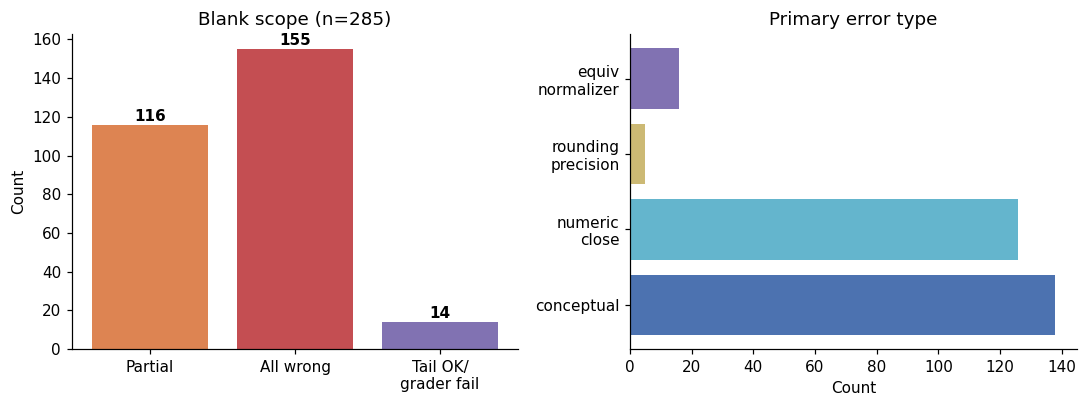

In [31]:
_GRADER_REL = 1e-8 * 1.01
_CLOSE_REL_HI = 0.05
_SLOT_PRI = [
    "equiv_normalizer",
    "rounding_precision",
    "numeric_close",
    "conceptual",
]


def _rel_err_numeric(pred_s: str, gold_s: str):
    try:
        pv, gv = float(pred_s), float(gold_s)
        if gv == 0:
            return 0.0 if pv == 0 else None
        return abs((pv - gv) / gv)
    except Exception:
        return None


def _rounding_mismatch(pred_s: str, gold_s: str) -> bool:
    re = _rel_err_numeric(pred_s, gold_s)
    if re is None or re <= _GRADER_REL:
        return False
    try:
        pv, gv = float(pred_s), float(gold_s)
    except Exception:
        return False
    for dp in range(1, 7):
        if round(pv, dp) == round(gv, dp):
            return True
    return False


def _classify_wrong_slot(judger, pred_s: str, gold_s: str) -> str:
    pn = judger.norm_ans_str(pred_s)
    gn = judger.norm_ans_str(gold_s)
    if judger.is_equal(pn, gn, options=[]):
        return "slot_ok"
    if _norm_box(judger, pred_s) == _norm_box(judger, gold_s):
        return "equiv_normalizer"
    re = _rel_err_numeric(pn, gn) or _rel_err_numeric(pred_s, gold_s)
    if re is not None and _GRADER_REL < re <= _CLOSE_REL_HI:
        return "numeric_close"
    if _rounding_mismatch(pred_s, gold_s):
        return "rounding_precision"
    return "conceptual"


def _classify_wrong_value_row(judger, boxes, gold):
    gold = _gold_list(gold)
    slots = [_classify_wrong_slot(judger, b, g) for b, g in zip(boxes, gold)]
    n_ok = sum(s == "slot_ok" for s in slots)
    wrong_types = [s for s in slots if s != "slot_ok"]
    n = len(gold)
    if n_ok == 0:
        blank_scope = "all_blanks_wrong"
    elif n_ok < n:
        blank_scope = "one_blank_wrong"
    else:
        blank_scope = "tail_match_grader_fail"
    if wrong_types:
        primary = min(wrong_types, key=lambda t: _SLOT_PRI.index(t))
    else:
        primary = "equiv_normalizer"
    return blank_scope, primary, n_ok, n, slots


if _judger is None:
    print("Judger unavailable — skip wrong-value taxonomy.\n")
else:
    wrong_vals_df = ff_fmt.loc[
        ff_fmt["count_ok"] & ~ff_fmt["correct"] & ~ff_fmt["wrong_order"]
    ].copy()
    tax_rows = []
    for _, row in wrong_vals_df.iterrows():
        scope, primary, n_ok, n_blanks, slots = _classify_wrong_value_row(
            _judger, row["boxed"], row["gold"]
        )
        tax_rows.append(
            {
                "id": row["id"],
                "n_blanks": n_blanks,
                "n_slots_ok": n_ok,
                "blank_scope": scope,
                "primary_error": primary,
                "slot_tags": slots,
            }
        )
    ff_value_tax = pd.DataFrame(tax_rows)
    n_wv = len(ff_value_tax)

    print(f"Wrong-value taxonomy (count-ok, not reorder): n={n_wv}\n")
    print("Blank scope (position-wise slot match vs gold):")
    for scope, label in [
        ("one_blank_wrong", "Partial (some blanks correct)"),
        ("all_blanks_wrong", "All blanks wrong"),
        ("tail_match_grader_fail", "Tail slots OK, grader still false"),
    ]:
        k = (ff_value_tax.blank_scope == scope).sum()
        print(f"  {label:<32} {k:>4}  ({100 * k / n_wv:.1f}%)")
    print()
    print("Primary error among wrong slots (priority: equiv → round → close → conceptual):")
    for tag, label in [
        ("equiv_normalizer", "Equiv. missed by normalizer"),
        ("rounding_precision", "Rounding / precision mismatch"),
        ("numeric_close", "Numeric close, outside tol"),
        ("conceptual", "Conceptual / math error"),
    ]:
        k = (ff_value_tax.primary_error == tag).sum()
        print(f"  {label:<32} {k:>4}  ({100 * k / n_wv:.1f}%)")
    print()

    cross = pd.crosstab(ff_value_tax.blank_scope, ff_value_tax.primary_error)
    print("Cross-tab (blank scope × primary error):\n")
    display(cross)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    scope_counts = ff_value_tax.blank_scope.value_counts().reindex(
        ["one_blank_wrong", "all_blanks_wrong", "tail_match_grader_fail"]
    ).fillna(0).astype(int)
    axes[0].bar(
        ["Partial", "All wrong", "Tail OK/\ngrader fail"],
        scope_counts.values,
        color=["#DD8452", "#C44E52", "#8172B2"],
    )
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Blank scope (n={n_wv})")
    for i, v in enumerate(scope_counts.values):
        axes[0].text(i, v + 2, str(v), ha="center", fontweight="bold")

    pri_counts = (
        ff_value_tax.primary_error.value_counts()
        .reindex(_SLOT_PRI)
        .fillna(0)
        .astype(int)
    )
    axes[1].barh(
        [t.replace("_", "\n") for t in pri_counts.index],
        pri_counts.values,
        color=["#8172B2", "#CCB974", "#64B5CD", "#4C72B0"],
    )
    axes[1].set_xlabel("Count")
    axes[1].set_title("Primary error type")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()

## 5. Response length analysis

In [12]:
for label, mask in [("MCQ", df.is_mcq), ("Free-form", ~df.is_mcq)]:
    sub = df[mask]
    print(f"{label}  correct mean: {sub[sub.correct].resp_len.mean():,.0f} chars   "
          f"wrong mean: {sub[~sub.correct].resp_len.mean():,.0f} chars")

MCQ  correct mean: 20,485 chars   wrong mean: 33,853 chars
Free-form  correct mean: 7,081 chars   wrong mean: 18,780 chars


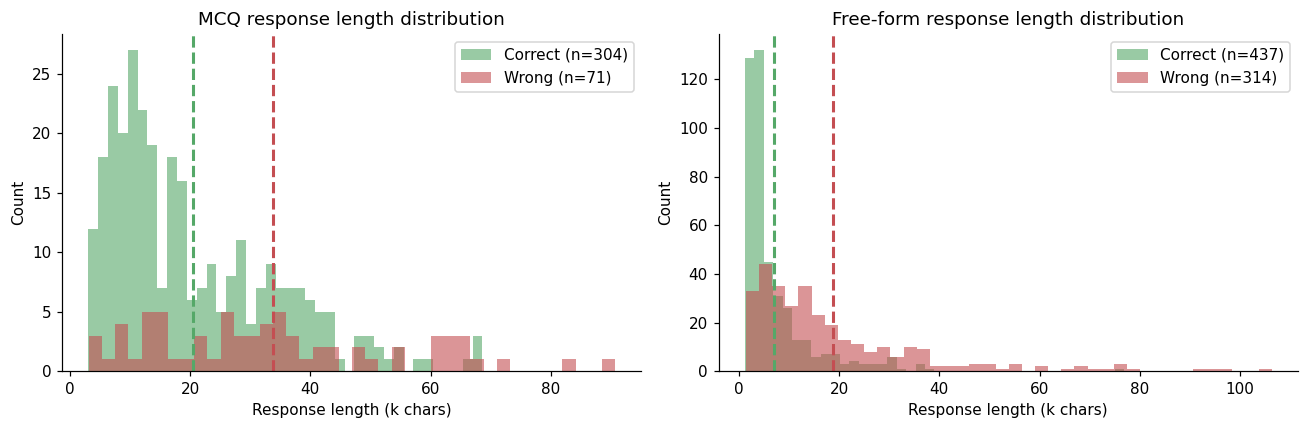

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (label, mask) in zip(axes, [("MCQ", df.is_mcq), ("Free-form", ~df.is_mcq)]):
    sub = df[mask]
    corr  = sub[sub.correct].resp_len / 1000
    wrong = sub[~sub.correct].resp_len / 1000
    ax.hist(corr,  bins=40, alpha=0.6, color="#55A868", label=f"Correct (n={len(corr)})")
    ax.hist(wrong, bins=40, alpha=0.6, color="#C44E52", label=f"Wrong (n={len(wrong)})")
    ax.axvline(corr.mean(),  color="#55A868", lw=2, linestyle="--")
    ax.axvline(wrong.mean(), color="#C44E52", lw=2, linestyle="--")
    ax.set_xlabel("Response length (k chars)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} response length distribution")
    ax.legend()

plt.tight_layout()
plt.show()

## 5b. Budget utilization — 16k→32k length delta

Most traces barely grew when `max_tokens` doubled (16k → 32k): the median length increase is small, while a long tail and a handful of near-cap runs absorb extra budget. Longer 32k traces are also more often wrong, which supports treating **overthinking** (extra reasoning without a better extracted answer) as a failure mode — especially for **R→W** regressions in §7b.

16k → 32k response length delta (chars)
  n:       1126
  mean:        673
  median:       52
  p90:       7,111
  p95:      13,856
  max:      53,392

32k near cap (≥79,000 chars): 6 / 1126 (0.5%)

32k trace length by graded outcome
  correct mean:   12,580 chars
  wrong mean:     21,560 chars
  ratio wrong/correct: 1.71×

MCQ  correct mean: 20,485   wrong mean: 33,853

Free-form  correct mean: 7,081   wrong mean: 18,780

Length delta by paired outcome (16k → 32k):
  W→R (budget helped)    n=  60  mean Δ=   2,878  median Δ= 1,928
  R→W (overthinking?)    n=  16  mean Δ=   1,267  median Δ=  -295
  both correct           n= 681  mean Δ=    -191  median Δ=     2
  both wrong             n= 369  mean Δ=   1,883  median Δ=   121

32k accuracy by response-length quartile:
Quartile          N  Accuracy
------------------------------
Q1 (short)      282     85.5%
Q2              281     68.7%
Q3              281     59.1%
Q4 (long)       282     50.0%


/tmp/ipykernel_24465/2237946415.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=["Correct", "Wrong"], patch_artist=True, widths=0.5)


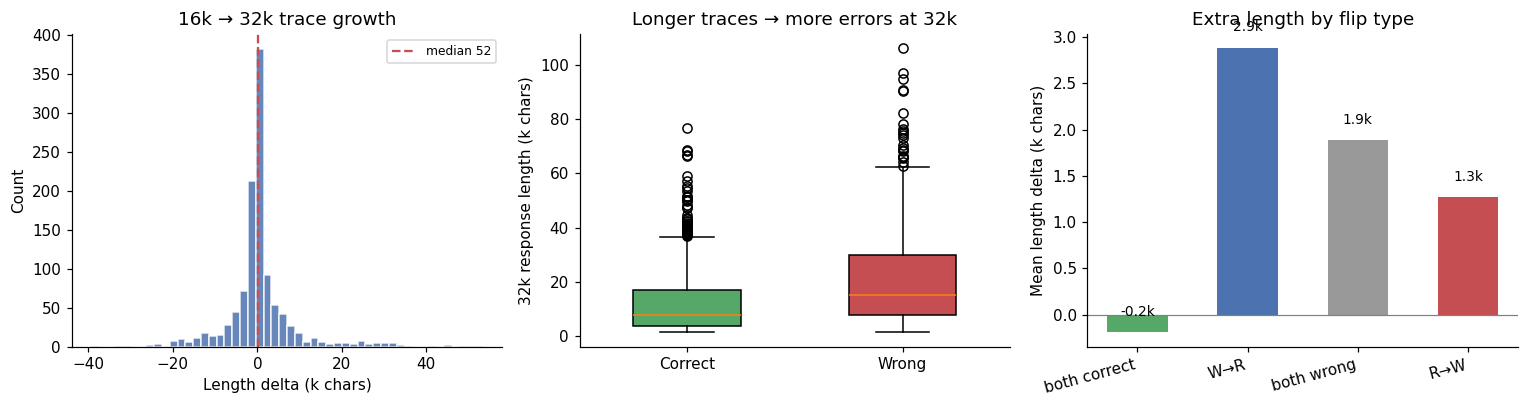

In [32]:
_prev_tag = "16k"
_prev_resp_path = os.path.join(REPO_ROOT, "data", f"full_public_{_prev_tag}.responses.jsonl")
_prev_results_path = os.path.join(REPO_ROOT, "data", f"full_public_{_prev_tag}.jsonl")

resp_len_16k = {r["id"]: len(r["response"]) for r in load_jsonl(_prev_resp_path)}
correct_16k = {r["id"]: r["correct"] for r in load_jsonl(_prev_results_path)}

budget = df.copy()
budget["resp_len_16k"] = budget["id"].map(resp_len_16k)
budget["correct_16k"] = budget["id"].map(correct_16k)
budget["len_delta"] = budget.resp_len - budget.resp_len_16k
budget = budget.dropna(subset=["resp_len_16k", "correct_16k"]).astype({"correct_16k": bool})

d = budget.len_delta
print("16k → 32k response length delta (chars)")
print(f"  n:      {len(d):>5}")
print(f"  mean:   {d.mean():>8,.0f}")
print(f"  median: {d.median():>8,.0f}")
print(f"  p90:    {d.quantile(0.9):>8,.0f}")
print(f"  p95:    {d.quantile(0.95):>8,.0f}")
print(f"  max:    {d.max():>8,.0f}")
near = int(budget.near_cap_chars.sum())
print(f"\n32k near cap (≥{NEAR_CAP_CHARS:,} chars): {near} / {len(budget)} ({100 * near / len(budget):.1f}%)")

corr_m = budget.loc[budget.correct, "resp_len"].mean()
wrong_m = budget.loc[~budget.correct, "resp_len"].mean()
print("\n32k trace length by graded outcome")
print(f"  correct mean: {corr_m:>8,.0f} chars")
print(f"  wrong mean:   {wrong_m:>8,.0f} chars")
print(f"  ratio wrong/correct: {wrong_m / corr_m:.2f}×")

for label, mask in [("MCQ", budget.is_mcq), ("Free-form", ~budget.is_mcq)]:
    sub = budget[mask]
    print(f"\n{label}  correct mean: {sub[sub.correct].resp_len.mean():,.0f}   "
          f"wrong mean: {sub[~sub.correct].resp_len.mean():,.0f}")

budget["w2r"] = (~budget.correct_16k) & budget.correct
budget["r2w"] = budget.correct_16k & (~budget.correct)
budget["both_right"] = budget.correct_16k & budget.correct
budget["both_wrong"] = (~budget.correct_16k) & (~budget.correct)

print("\nLength delta by paired outcome (16k → 32k):")
for label, mask in [
    ("W→R (budget helped)", budget.w2r),
    ("R→W (overthinking?)", budget.r2w),
    ("both correct", budget.both_right),
    ("both wrong", budget.both_wrong),
]:
    sub = budget[mask]
    print(f"  {label:<22} n={len(sub):4d}  mean Δ={sub.len_delta.mean():>8,.0f}  "
          f"median Δ={sub.len_delta.median():>6,.0f}")

budget["len_quartile"] = pd.qcut(
    budget.resp_len, 4, labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"]
)
len_acc = (
    budget.groupby("len_quartile", observed=True)
    .agg(n=("correct", "count"), acc=("correct", lambda s: 100 * s.mean()))
)
print(f"\n32k accuracy by response-length quartile:")
print(f"{'Quartile':<12} {'N':>6} {'Accuracy':>9}")
print("-" * 30)
for q, row in len_acc.iterrows():
    print(f"{q:<12} {row.n:>6.0f} {row.acc:>8.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ax = axes[0]
ax.hist(d / 1000, bins=50, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(d.median() / 1000, color="#C44E52", ls="--", lw=1.5, label=f"median {d.median():,.0f}")
ax.set_xlabel("Length delta (k chars)")
ax.set_ylabel("Count")
ax.set_title("16k → 32k trace growth")
ax.legend(fontsize=8)

ax = axes[1]
box_data = [
    budget.loc[budget.correct, "resp_len"] / 1000,
    budget.loc[~budget.correct, "resp_len"] / 1000,
]
bp = ax.boxplot(box_data, labels=["Correct", "Wrong"], patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#55A868")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("32k response length (k chars)")
ax.set_title("Longer traces → more errors at 32k")

ax = axes[2]
outcome_order = ["both correct", "W→R", "both wrong", "R→W"]
outcome_masks = [
    budget.both_right,
    budget.w2r,
    budget.both_wrong,
    budget.r2w,
]
means = [budget[m].len_delta.mean() / 1000 for m in outcome_masks]
colors = ["#55A868", "#4C72B0", "#999999", "#C44E52"]
bars = ax.bar(outcome_order, means, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.8)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{m:.1f}k", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Mean length delta (k chars)")
ax.set_title("Extra length by flip type")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

## 6. Question length vs accuracy

In [14]:
corr_q  = df[df.correct].q_len.mean()
wrong_q = df[~df.correct].q_len.mean()
print(f"Correct question mean length:   {corr_q:.0f} chars")
print(f"Incorrect question mean length: {wrong_q:.0f} chars")

df["q_quartile"] = pd.qcut(df.q_len, 4, labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"])
q_acc = df.groupby("q_quartile", observed=True).agg(n=("correct", "count"), acc=("correct", "mean")).reset_index()
q_acc["acc"] *= 100
print()
print(q_acc.to_string(index=False))

Correct question mean length:   303 chars
Incorrect question mean length: 511 chars

q_quartile   n       acc
Q1 (short) 283 79.858657
        Q2 281 71.530249
        Q3 281 63.345196
 Q4 (long) 281 48.398577


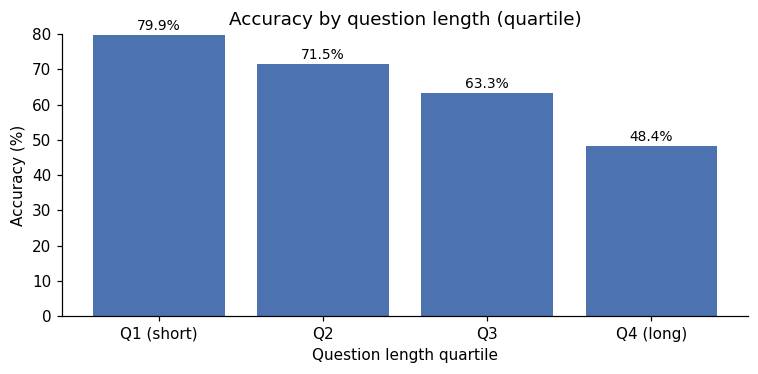

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(q_acc.q_quartile.astype(str), q_acc.acc, color="#4C72B0")
for bar, row in zip(bars, q_acc.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.acc + 0.5,
            f"{row.acc:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Question length quartile")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by question length (quartile)")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

## 7. Topic-level breakdown

In [16]:
from scripts.topic_classify import (
    aggregate_topics,
    classify_topic,
)


if os.path.isfile(TOPICS_PATH):
    with open(TOPICS_PATH) as f:
        topics_agg = json.load(f)
    print(f"Loaded topics from {TOPICS_PATH}")
else:
    questions_by_id = {rid: pub_map[rid]["question"] for rid in pub_map}
    topics_agg = aggregate_topics(results, questions_by_id)
    with open(TOPICS_PATH, "w") as f:
        json.dump(topics_agg, f, indent=2)
    print(f"Computed topics → {TOPICS_PATH}")

Loaded topics from /home/andrewyin/UCSD-CSE-Programming-Assignments/CSE151B/151B_SP26_Competition/data/full_public_32k_topics.json


In [17]:
topic_rows = []
for topic, v in topics_agg.items():
    topic_rows.append({
        "topic":        topic,
        "n":            v["n"],
        "correct":      v["correct"],
        "accuracy":     v["accuracy"],
        "mcq_n":        v["mcq_n"],
        "mcq_correct":  v["mcq_correct"],
        "mcq_accuracy": v["mcq_accuracy"],
    })

tdf = pd.DataFrame(topic_rows).sort_values("accuracy")

print(f"{'Topic':<30} {'N':>6} {'Acc':>7} {'MCQ N':>6} {'MCQ Acc':>9}")
print("-" * 65)
for _, r in tdf.iterrows():
    ma = r.mcq_accuracy if r.mcq_accuracy is not None else float("nan")
    print(f"{r.topic:<30} {r.n:>6} {r.accuracy:>6.1f}% {r.mcq_n:>6} {ma:>8.1f}%")

Topic                               N     Acc  MCQ N   MCQ Acc
-----------------------------------------------------------------
logs/exponents                     31   51.6%      4     50.0%
probability/stats                 205   51.7%     30     86.7%
trigonometry                       65   53.9%     16     81.2%
geometry                          108   57.4%     40     82.5%
arithmetic/word problems          146   63.7%      9     77.8%
limits                             13   69.2%      9     88.9%
derivatives                        21   71.4%     16     75.0%
polynomials/algebra               163   71.8%     24     91.7%
sequences/recurrences              56   73.2%     46     76.1%
number theory                      57   73.7%     42     85.7%
other                             167   76.0%     47     68.1%
linear algebra                     22   77.3%     21     81.0%
complex analysis                   13   84.6%     12     91.7%
integration                        59   84.8%     59

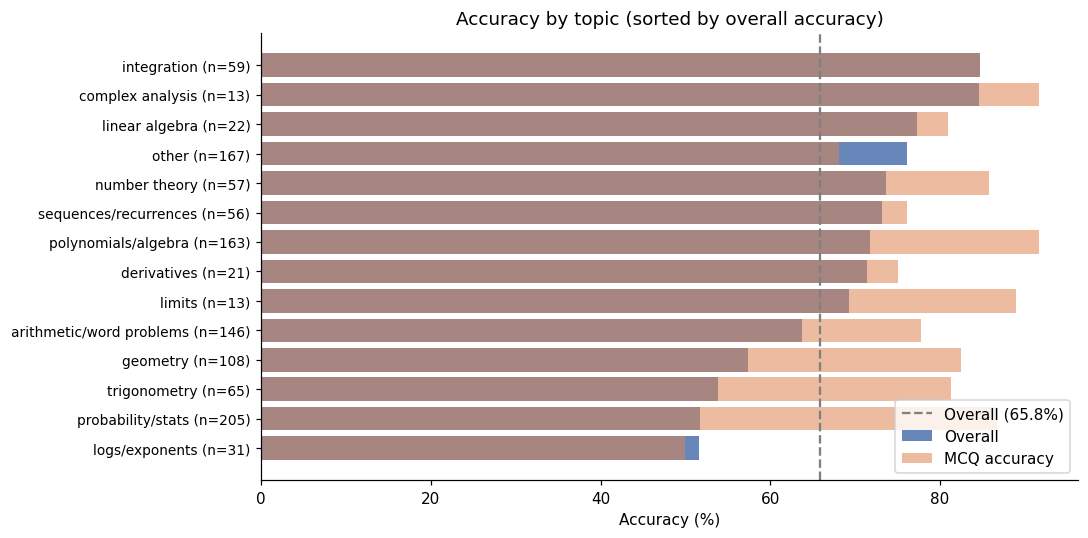

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(tdf))
ax.barh(list(y), tdf.accuracy, color="#4C72B0", alpha=0.85, label="Overall")
ax.barh(list(y), tdf.mcq_accuracy.fillna(0), color="#DD8452", alpha=0.55, label="MCQ accuracy")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{t} (n={n})" for t, n in zip(tdf.topic, tdf.n)], fontsize=9)
ax.axvline(all_acc, color="gray", linestyle="--", lw=1.5, label=f"Overall ({all_acc:.1f}%)")
ax.set_xlabel("Accuracy (%)")
ax.set_title("Accuracy by topic (sorted by overall accuracy)")
ax.legend()
plt.tight_layout()
plt.show()

## 7b. Paired 16k → 32k flip analysis

Item-level comparison between pub-002 (`data/full_public_16k.jsonl`) and this run (32k). **W→R** = wrong at 16k, correct at 32k; **R→W** = correct at 16k, wrong at 32k. Slice tables show where extra budget helped or hurt; the topic delta table and R→W samples highlight uneven gains and overthinking regressions.

In [22]:
PREV_TAG = "16k"
PREV_RESULTS_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{PREV_TAG}.jsonl")
PREV_RESPONSES_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{PREV_TAG}.responses.jsonl")
PREV_TOPICS_PATH = os.path.join(REPO_ROOT, "data", f"full_public_{PREV_TAG}_topics_weighted_v1.json")

results_16k = load_jsonl(PREV_RESULTS_PATH)
resp_16k_map = {r["id"]: r["response"] for r in load_jsonl(PREV_RESPONSES_PATH)}
correct_16k = {r["id"]: r["correct"] for r in results_16k}

paired = df.copy()
paired["correct_16k"] = paired["id"].map(correct_16k)
paired["correct_32k"] = paired["correct"]
paired["response_16k"] = paired["id"].map(resp_16k_map)
paired["topic"] = paired["question"].map(classify_topic)
paired["w2r"] = (~paired.correct_16k) & paired.correct_32k
paired["r2w"] = paired.correct_16k & (~paired.correct_32k)

missing = paired["correct_16k"].isna().sum()
assert missing == 0, f"{missing} ids missing from 16k results"

def _flip_counts(sub):
    w2r = int(sub.w2r.sum())
    r2w = int(sub.r2w.sum())
    return w2r, r2w, w2r - r2w

def flip_slice_table(sub, group_col, title):
    rows = []
    for key, g in sub.groupby(group_col, observed=True, sort=False):
        w2r, r2w, net = _flip_counts(g)
        rows.append({"slice": str(key), "n": len(g), "W→R": w2r, "R→W": r2w, "net": net})
    out = pd.DataFrame(rows)
    print(f"\n{title}")
    print(f"{'slice':<28} {'n':>6} {'W→R':>6} {'R→W':>6} {'net':>6}")
    print("-" * 58)
    for _, r in out.iterrows():
        print(f"{r.slice:<28} {r.n:>6} {r['W→R']:>6} {r['R→W']:>6} {r.net:>+6}")
    return out

wr, rw, net = _flip_counts(paired)
mcq_wr, mcq_rw, mcq_net = _flip_counts(paired[paired.is_mcq])
ff_wr, ff_rw, ff_net = _flip_counts(paired[~paired.is_mcq])

print("=" * 62)
print("Paired flip summary: 16k → 32k")
print("=" * 62)
print(f"{'Slice':<14} {'W→R':>6} {'R→W':>6} {'net':>6}")
print("-" * 36)
print(f"{'Overall':<14} {wr:>6} {rw:>6} {net:>+6}")
print(f"{'MCQ':<14} {mcq_wr:>6} {mcq_rw:>6} {mcq_net:>+6}")
print(f"{'Free-form':<14} {ff_wr:>6} {ff_rw:>6} {ff_net:>+6}")
print("=" * 62)

if "q_quartile" not in paired.columns:
    paired["q_quartile"] = pd.qcut(paired.q_len, 4, labels=["Q1 (short)", "Q2", "Q3", "Q4 (long)"])

def _blank_group(n):
    if n <= 5:
        return str(int(n))
    if n <= 10:
        return "6–10"
    return "11+"

paired["blank_group"] = paired.n_blanks.map(_blank_group)

paired["type_label"] = np.where(paired.is_mcq, "MCQ", "free-form")
flip_slice_table(paired, "type_label", "By question type")
flip_slice_table(paired, "blank_group", "By blank count (grouped)")
flip_slice_table(paired, "topic", "By topic")
flip_slice_table(paired, "q_quartile", "By question-length quartile")

Paired flip summary: 16k → 32k
Slice             W→R    R→W    net
------------------------------------
Overall            60     16    +44
MCQ                41      7    +34
Free-form          19      9    +10

By question type
slice                             n    W→R    R→W    net
----------------------------------------------------------
free-form                       751     19      9    +10
MCQ                             375     41      7    +34

By blank count (grouped)
slice                             n    W→R    R→W    net
----------------------------------------------------------
1                               712     49     10    +39
2                               171      2      3     -1
3                                90      3      0     +3
4                                59      3      1     +2
11+                              10      1      0     +1
5                                31      1      0     +1
6–10                             53      1      2     -1

,slice,n,W→R,R→W,net
0,Q1 (short),283,7,4,3
1,Q3,281,17,6,11
2,Q2,281,22,5,17
3,Q4 (long),281,14,1,13


Topic                             16k %    32k %    Δ pp      n
-----------------------------------------------------------------
number theory                     57.9%    73.7%   +15.8     57
complex analysis                  69.2%    84.6%   +15.4     13
sequences/recurrences             62.5%    73.2%   +10.7     56
limits                            61.5%    69.2%    +7.7     13
geometry                          52.8%    57.4%    +4.6    108
linear algebra                    72.7%    77.3%    +4.5     22
polynomials/algebra               68.1%    71.8%    +3.7    163
arithmetic/word problems          60.3%    63.7%    +3.4    146
other                             73.0%    76.0%    +3.0    167
probability/stats                 49.8%    51.7%    +2.0    205
integration                       84.8%    84.8%    +0.0     59
logs/exponents                    51.6%    51.6%    +0.0     31
derivatives                       71.4%    71.4%    +0.0     21
trigonometry                      53.9

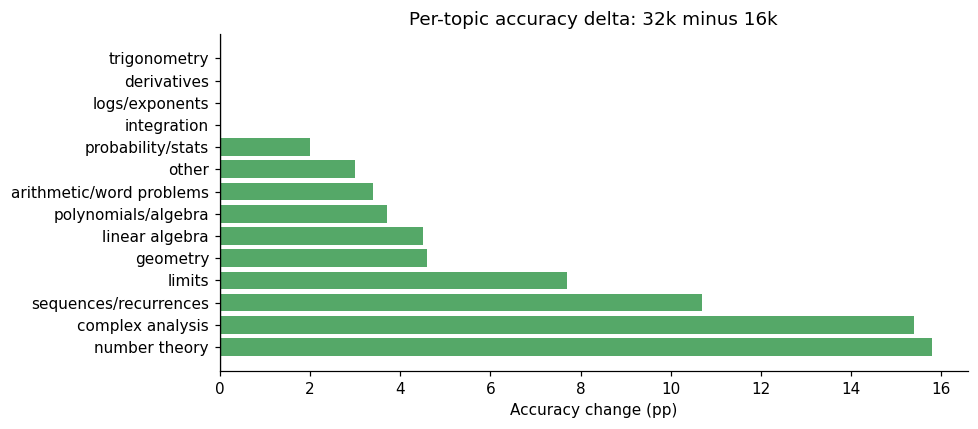

In [23]:
with open(PREV_TOPICS_PATH) as f:
    topics_16k = json.load(f)

topic_delta_32 = []
for topic, v in topics_agg.items():
    acc32 = v["accuracy"]
    acc16 = topics_16k.get(topic, {}).get("accuracy")
    delta = round(acc32 - acc16, 1) if acc16 is not None else None
    topic_delta_32.append({
        "topic": topic,
        "acc_16k": acc16,
        "acc_32k": acc32,
        "delta_pp": delta,
        "n": v["n"],
    })

delta32_df = pd.DataFrame(topic_delta_32).sort_values("delta_pp", ascending=False)

print(f"{'Topic':<30} {'16k %':>8} {'32k %':>8} {'Δ pp':>7}  {'n':>5}")
print("-" * 65)
for _, r in delta32_df.iterrows():
    a16 = f"{r.acc_16k:.1f}%" if r.acc_16k is not None else "  n/a"
    d = f"{r.delta_pp:+.1f}" if r.delta_pp is not None else "  n/a"
    print(f"{r.topic:<30} {a16:>8} {r.acc_32k:>7.1f}% {d:>7}  {r.n:>5.0f}")

fig, ax = plt.subplots(figsize=(9, 4))
d = delta32_df.dropna(subset=["delta_pp"])
colors = ["#55A868" if v >= 0 else "#C44E52" for v in d.delta_pp]
ax.barh(d.topic, d.delta_pp, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Accuracy change (pp)")
ax.set_title("Per-topic accuracy delta: 32k minus 16k")
plt.tight_layout()
plt.show()

In [24]:
from judger import Judger

_j = Judger(strict_extract=False)

def _pred_display(resp, is_mcq):
    if not isinstance(resp, str) or not resp:
        return "(empty)"
    if is_mcq:
        m = re.search(r"\\boxed\{([A-Z])\}", resp)
        if m:
            return m.group(1)
        return _j.extract_boxed_answer(resp) or "(no boxed letter)"
    boxes = _j.extract_all_boxed(resp)
    return boxes if boxes else "(no boxes)"

regress = paired[paired.r2w].sort_values(["is_mcq", "topic", "id"])
n_show = min(20, len(regress))
print(f"R→W regression samples (16k correct → 32k wrong): showing {n_show} / {len(regress)}")
print("=" * 72)

for _, row in regress.head(n_show).iterrows():
    p16 = _pred_display(row.response_16k, row.is_mcq)
    p32 = _pred_display(row.response, row.is_mcq)
    q_snip = re.sub(r"\s+", " ", row.question)[:180]
    print(f"\nid {row.id}  |  {('MCQ' if row.is_mcq else 'FF')}  |  topic={row.topic}  |  blanks={row.n_blanks}")
    print(f"  gold:     {row.gold}")
    print(f"  16k pred: {p16}   (len={len(row.response_16k):,}, think_done={'</think>' in row.response_16k})")
    print(f"  32k pred: {p32}   (len={row.resp_len:,}, think_done={row.think_finished})")
    print(f"  Q: {q_snip}{'…' if len(row.question) > 180 else ''}")

R→W regression samples (16k correct → 32k wrong): showing 16 / 16

id 396  |  FF  |  topic=arithmetic/word problems  |  blanks=2
  gold:     ['17', '14']
  16k pred: ['17', '14']   (len=3,478, think_done=True)
  32k pred: ['14', '17', '14']   (len=3,557, think_done=True)
  Q: A man has 31 coins in his pocket, all of which are dimes and quarters. If the total value of his change is 520 cents, how many dimes and how many quarters does he have? Your answer…

id 980  |  FF  |  topic=arithmetic/word problems  |  blanks=2
  gold:     ['1957.2', '660']
  16k pred: ['1957.20', '660']   (len=7,139, think_done=True)
  32k pred: ['660', '1957.20', '660']   (len=4,932, think_done=True)
  Q: In a city, the property tax rate for per thousand dollars of property value is ${\$4.66}$. Fill in blanks: Question 1: The owner of a house worth $420$ thousand dollars should pay …

id 1057  |  FF  |  topic=geometry  |  blanks=1
  gold:     ['(0,4.5)']
  16k pred: ['(0.000, 4.500)']   (len=4,914, think_done=Tr

## 8. Truncation check

In [25]:
trunc_all = (~df.think_finished).sum()
trunc_mcq = (~mcq.think_finished).sum()
trunc_ff  = (~ff.think_finished).sum()

print("Responses truncated mid-think (no </think> tag):")
print(f"  Overall:   {trunc_all} / {len(df)} ({100*trunc_all/len(df):.1f}%)")
print(f"  MCQ:       {trunc_mcq} / {len(mcq)} ({100*trunc_mcq/len(mcq):.1f}%)")
print(f"  Free-form: {trunc_ff} / {len(ff)} ({100*trunc_ff/len(ff):.1f}%)")
print()

trunc_df = df[~df.think_finished]
if len(trunc_df):
    mean_chars = trunc_df.resp_len.mean()
    est_ctok   = mean_chars / MAX_TOKENS
    print(f"Mean chars of truncated responses: {mean_chars:,.0f}")
    print(f"Implied chars/token at {MAX_TOKENS//1024}k cap: {est_ctok:.2f}")
print()

print("Accuracy by truncation status:")
for label, mask in [("Think finished", df.think_finished), ("Think truncated", ~df.think_finished)]:
    sub = df[mask]
    print(f"  {label:<20} n={len(sub):>4}  acc={100*sub.correct.mean():.1f}%")

old_trunc = df.near_cap_chars.sum()
print()
print(f"Legacy char-heuristic (≥{NEAR_CAP_CHARS//1000}k): {old_trunc}  |  tag-based truncated: {trunc_all}")

Responses truncated mid-think (no </think> tag):
  Overall:   11 / 1126 (1.0%)
  MCQ:       6 / 375 (1.6%)
  Free-form: 5 / 751 (0.7%)

Mean chars of truncated responses: 76,538
Implied chars/token at 32k cap: 2.34

Accuracy by truncation status:
  Think finished       n=1115  acc=66.3%
  Think truncated      n=  11  acc=18.2%

Legacy char-heuristic (≥79k): 6  |  tag-based truncated: 11


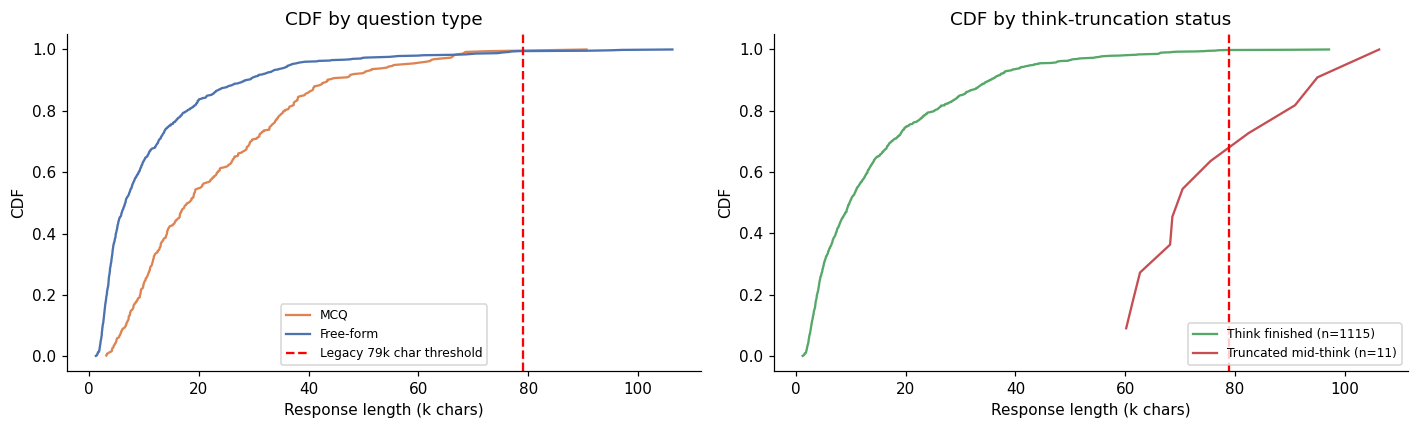

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for label, sub, color in [("MCQ", mcq, "#DD8452"), ("Free-form", ff, "#4C72B0")]:
    s = np.sort(sub.resp_len / 1000)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=label, color=color)
ax.axvline(NEAR_CAP_CHARS / 1000, color="red", linestyle="--", lw=1.5, label=f"Legacy {NEAR_CAP_CHARS//1000}k char threshold")
ax.set_xlabel("Response length (k chars)")
ax.set_ylabel("CDF")
ax.set_title("CDF by question type")
ax.legend(fontsize=8)

ax = axes[1]
for label, mask, color in [
    ("Think finished", df.think_finished, "#55A868"),
    ("Truncated mid-think", ~df.think_finished, "#C44E52"),
]:
    sub = df[mask]
    s = np.sort(sub.resp_len / 1000)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), label=f"{label} (n={len(sub)})", color=color)
ax.axvline(NEAR_CAP_CHARS / 1000, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Response length (k chars)")
ax.set_ylabel("CDF")
ax.set_title("CDF by think-truncation status")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Summary table

In [28]:
best_topic  = tdf.iloc[-1]
weak_topic  = tdf.iloc[0]

try:
    _wv_scope = (
        f"{int((ff_value_tax.blank_scope == 'one_blank_wrong').sum())} one-blank-wrong; "
        f"{int((ff_value_tax.blank_scope == 'all_blanks_wrong').sum())} all-blanks-wrong"
    )
    _wv_primary = "; ".join(
        f"{int((ff_value_tax.primary_error == t).sum())} {t.replace('_', ' ')}"
        for t in _SLOT_PRI
    )
except NameError:
    _wv_scope = _wv_primary = "run §4c first"

summary = pd.DataFrame([
    {"Metric": "Overall accuracy", "Value": f"{all_acc:.2f}%  ({all_k}/{all_n})"},
    {"Metric": "MCQ accuracy", "Value": f"{mcq_acc:.2f}%  ({mcq_k}/{mcq_n})"},
    {"Metric": "Free-form accuracy", "Value": f"{ff_acc:.2f}%  ({ff_k}/{ff_n})"},
    {"Metric": "MCQ with \\boxed{X}", "Value": f"{len(strict_n)} / {len(mcq)}  ({100*len(strict_n)/len(mcq):.1f}%)"},
    {"Metric": "MCQ correct | has \\boxed{X}", "Value": f"{100*boxed_rate:.1f}%"},
    {"Metric": "Wrong MCQ: truncated mid-think", "Value": f"{truncated} / {len(wrong_mcq)} ({100*truncated/len(wrong_mcq):.0f}%)"},
    {"Metric": "Wrong MCQ: think done (format/reasoning)", "Value": f"{finished_no_box + wrong_box} / {len(wrong_mcq)}"},
    {"Metric": "Free-form single-blank accuracy", "Value": f"{100*single.correct.mean():.1f}%  (n={len(single)})"},
    {"Metric": "Free-form multi-blank accuracy", "Value": f"{100*multi.correct.mean():.1f}%  (n={len(multi)})"},
    {"Metric": "FF box count == blanks", "Value": f"{len(count_ok_ff)} / {len(ff_fmt)}  ({100*len(count_ok_ff)/len(ff_fmt):.1f}%)"},
    {"Metric": "FF misformat (count ≠ blanks)", "Value": f"{len(format_bad_ff)} / {len(ff_fmt)}  (0% correct)"},
    {"Metric": "Wrong FF: misformat / order / values", "Value": f"{ff_misformat} misformat; {ff_wrong_order} wrong order; {ff_wrong_values} wrong values"},
    {"Metric": "Wrong FF values: blank scope", "Value": _wv_scope},
    {"Metric": "Wrong FF values: primary error", "Value": _wv_primary},
    {"Metric": "Think finished rate", "Value": f"{df.think_finished.sum()} / {len(df)} ({100*df.think_finished.mean():.1f}%)"},
    {"Metric": "Best topic", "Value": f"{best_topic.topic} — {best_topic.accuracy:.1f}% (n={best_topic.n})"},
    {"Metric": "Weakest topic", "Value": f"{weak_topic.topic} — {weak_topic.accuracy:.1f}% (n={weak_topic.n})"},
])

print(summary.to_string(index=False))

                                  Metric                                         Value
                        Overall accuracy                            65.81%  (741/1126)
                            MCQ accuracy                             81.07%  (304/375)
                      Free-form accuracy                             58.19%  (437/751)
                      MCQ with \boxed{X}                            367 / 375  (97.9%)
             MCQ correct | has \boxed{X}                                         82.3%
          Wrong MCQ: truncated mid-think                                   4 / 71 (6%)
Wrong MCQ: think done (format/reasoning)                                       67 / 71
         Free-form single-blank accuracy                                61.7%  (n=337)
          Free-form multi-blank accuracy                                55.3%  (n=414)
                  FF box count == blanks                            723 / 751  (96.3%)
           FF misformat (count ≠ blanks)   

## 10. Free-form accuracy by blank count (explicit table)

Bar chart from §4 aggregated into a clean numeric table; groups sparse high-blank-count bins for clarity.

In [29]:
def blank_label(n):
    if n <= 5:   return str(n)
    if n <= 10:  return "6–10"
    return "11+"

blank_table = (ff.groupby("n_blanks")
    .agg(n=("correct", "count"), correct=("correct", "sum"))
    .assign(accuracy=lambda x: 100 * x.correct / x.n)
    .reset_index())
blank_table["group"] = blank_table.n_blanks.apply(blank_label)

grouped = (blank_table.groupby("group", sort=False)
    .agg(n=("n", "sum"), correct=("correct", "sum"))
    .assign(accuracy=lambda x: 100 * x.correct / x.n))

ordered_groups = ["1", "2", "3", "4", "5", "6–10", "11+"]
grouped = grouped.reindex([g for g in ordered_groups if g in grouped.index])

print(f"{'Blanks':<8} {'N':>6} {'Correct':>9} {'Accuracy':>9}")
print("-" * 36)
for grp, row in grouped.iterrows():
    print(f"{grp:<8} {row.n:>6.0f} {row.correct:>9.0f} {row.accuracy:>8.1f}%")

print()
single_acc = grouped.loc["1",    "accuracy"] if "1"    in grouped.index else float("nan")
two_acc    = grouped.loc["2",    "accuracy"] if "2"    in grouped.index else float("nan")
high_acc   = grouped.loc["6–10", "accuracy"] if "6–10" in grouped.index else float("nan")
print(f"Trend: 1-blank {single_acc:.1f}%  →  2-blank {two_acc:.1f}%  →  6–10-blank {high_acc:.1f}%")
print("Accuracy decreases monotonically with blank count; multi-blank prompting is the primary lever.")

Blanks        N   Correct  Accuracy
------------------------------------
1           337       208     61.7%
2           171        99     57.9%
3            90        59     65.6%
4            59        35     59.3%
5            31        14     45.2%
6–10         53        17     32.1%
11+          10         5     50.0%

Trend: 1-blank 61.7%  →  2-blank 57.9%  →  6–10-blank 32.1%
Accuracy decreases monotonically with blank count; multi-blank prompting is the primary lever.
